# Data Preprocessing and Preliminary Plotting

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
from astropy.time import Time

### Importing the data
- shape (N, 2)
- 2 -> (BJD, S-index)

In [2]:
data = read_csv(r"../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True).to_numpy()

print(data.shape)
print(data[0])
time0 = data[1200,0]
print(time0)
t = Time(data[:,0], format="jd", scale='tdb')
print(f"Start in {t[0].jyear} = {t[0].jd}")
print(t.jd)
jd_0 = t[0].jd
jd = t.jd - jd_0
print(jd)

(1395, 2)
[2.4391948e+06 1.7560000e-01]
2449359.93213
Start in 1966.1869952087607 = 2439194.8
[2439194.8     2439486.8     2439515.8     ... 2449819.73779 2449819.73877
 2449819.74023]
[    0.        292.        321.      ... 10624.93779 10624.93877
 10624.94023]


C:\Users\Joey\AppData\Local\Temp\ipykernel_31040\2331333012.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = read_csv(r"../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True).to_numpy()


### Preliminary plotting

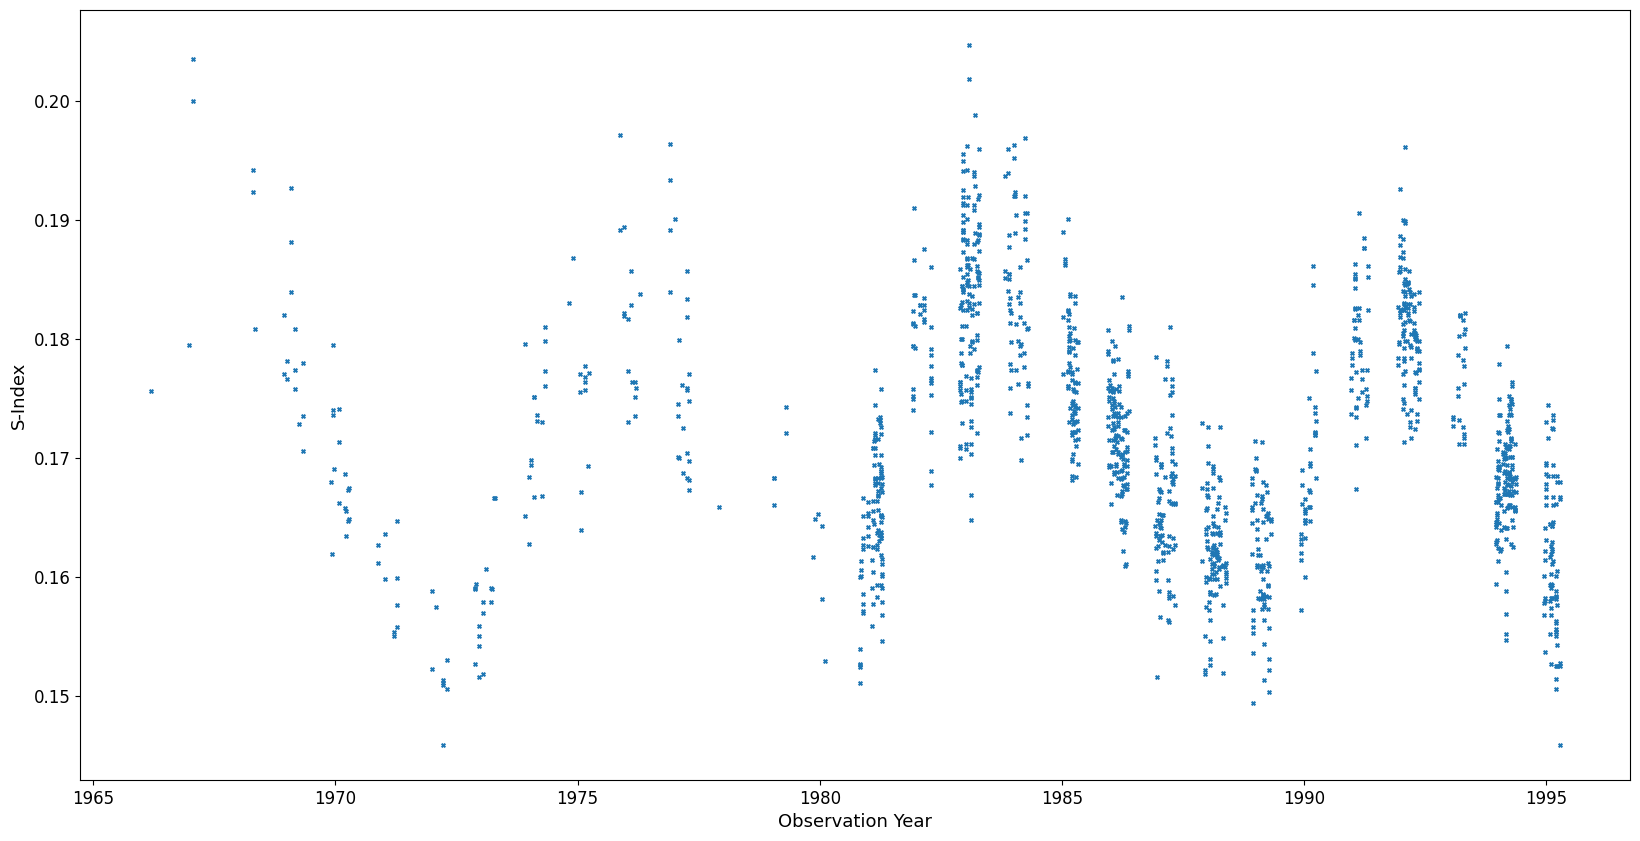

In [3]:
fig, ax = plt.subplots(1, figsize=(20, 10))
ax.scatter(t.jyear, data[:,1], marker='x', s=7, alpha=1)
ax.set_ylabel("S-Index", fontsize=13)
ax.set_xlabel("Observation Year", fontsize=13)
ax.tick_params(axis='both', labelsize=12)
# fig.savefig(r"../Report/Figures/WellSampledData_HD81809.png")
plt.show()

### Split train/valid/test in chronological order
- Let's split this 70/15/15 by datapoint number

In [4]:
dataset_length = len(data)
train_split = 0.7
valid_split = 0.15
# test_split = 1 - train_split - valid_split

train_idx = round(train_split*dataset_length)
valid_idx = round((valid_split + train_split) * dataset_length)

trainset = data[:train_idx]
validset = data[train_idx:valid_idx]
testset = data[valid_idx:]

print(trainset.shape, validset.shape, testset.shape)
print(1183 + 253+ 254)

(976, 2) (210, 2) (209, 2)
1690


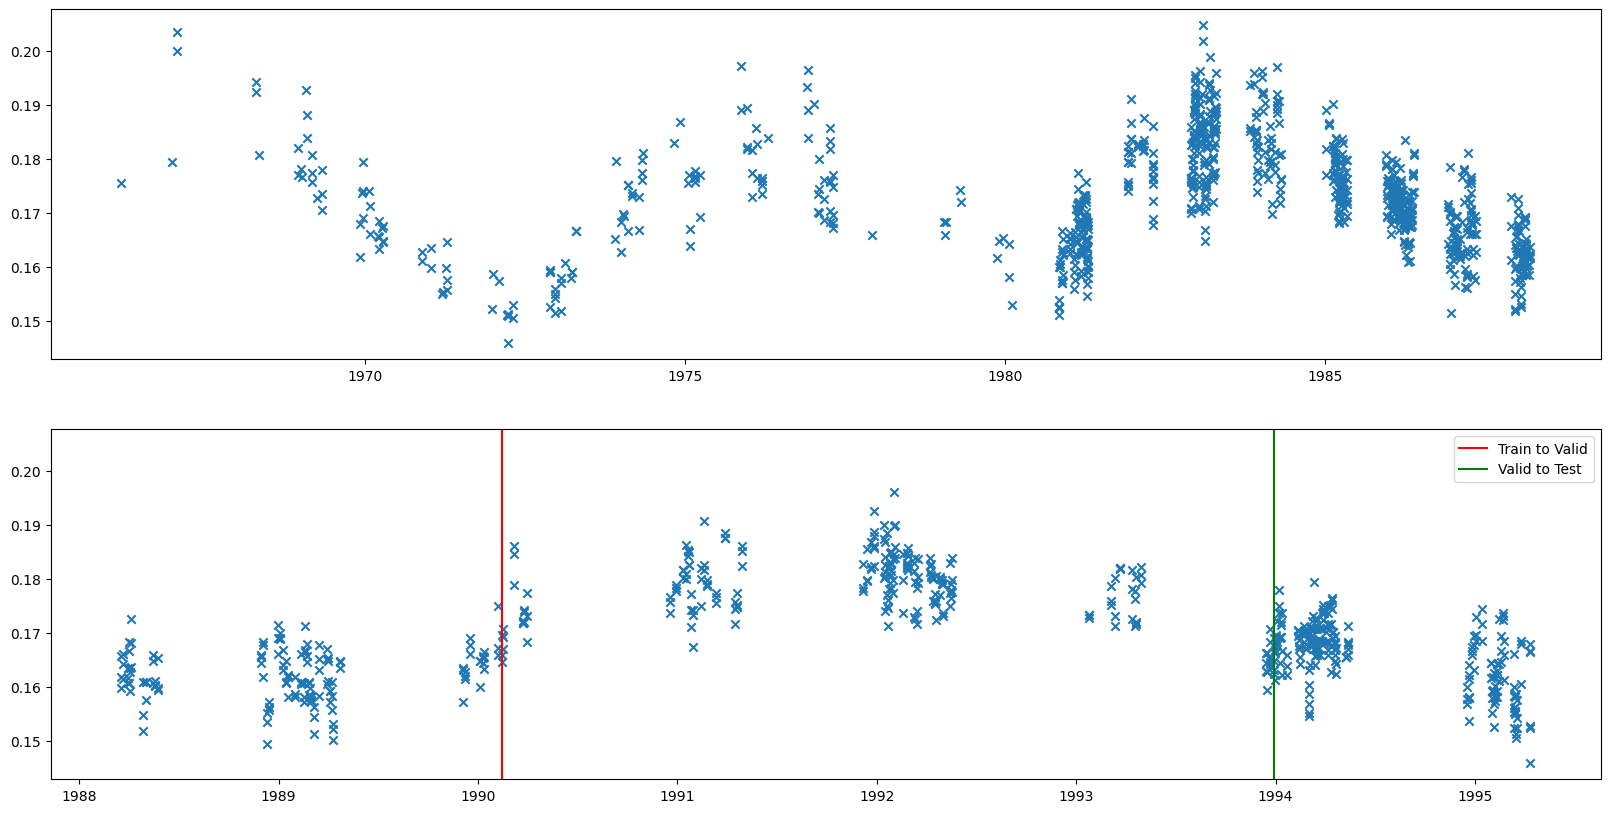

In [5]:
lim = 1690 //2
fig, ax = plt.subplots(2,1,figsize=(20,10), sharey =  True)
ax[0].scatter(t.jyear[:lim], data[:lim,1], marker="x")
ax[1].scatter(t.jyear[lim:], data[lim:,1], marker='x')
plt.axvline(t.jyear[train_idx], label = "Train to Valid", color = "red")
plt.axvline(t.jyear[valid_idx], label = "Valid to Test", color = "green")
plt.legend()
plt.show()

In [6]:
t.jyear[-1]

np.float64(1995.2764961806984)

In [7]:
t.jyear[0]

np.float64(1966.1869952087607)

- Now plot a poorly sampled dataset for illustration in the report.

C:\Users\Joey\AppData\Local\Temp\ipykernel_31040\3498403935.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = read_csv(r"../Data/mwd/hd166_caii.txt", sep='\s',skip_blank_lines=True).to_numpy()


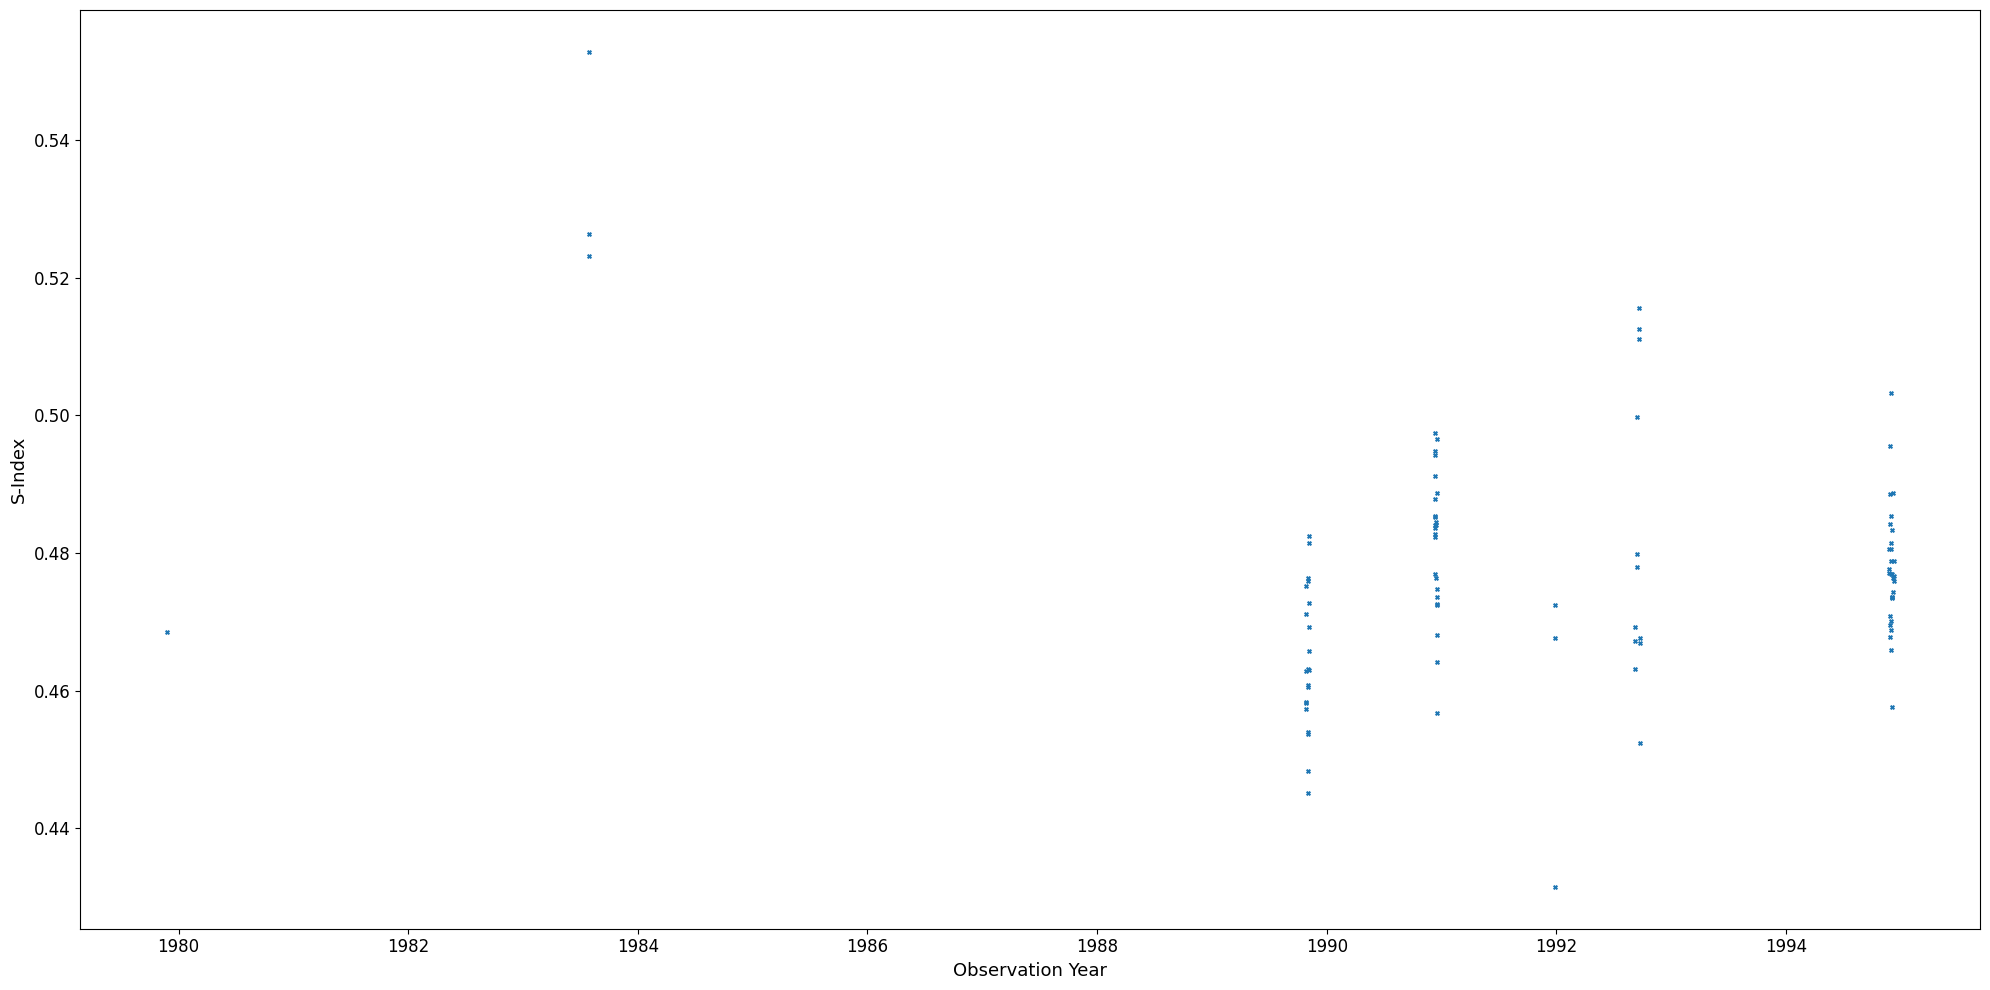

In [10]:
data = read_csv(r"../Data/mwd/hd166_caii.txt", sep='\s',skip_blank_lines=True).to_numpy()

# print(data.shape)
# print(data[0])
# time0 = data[1200,0]
# print(time0)
t = Time(data[:,0], format="jd", scale='tdb')
# print(f"Start in {t[0].jyear} = {t[0].jd}")
# print(t.jd)
jd_0 = t[0].jd
jd = t.jd - jd_0
# print(jd)

fig, ax = plt.subplots(1, figsize=(20, 10))
ax.scatter(t.jyear, data[:,1], marker='x', s=7, alpha=1)
ax.set_ylabel("S-Index", fontsize=13)
ax.set_xlabel("Observation Year", fontsize=13)
ax.tick_params(axis='both', labelsize=12)
plt.tight_layout()
fig.savefig(r"../Report/Figures/PoorlySampledData_HD166.png")
plt.show()

- Plot the baselines and Sun.

C:\Users\Joey\AppData\Local\Temp\ipykernel_31040\2694939231.py:4: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = read_csv(r"../Data/misc/sol_sind_all.txt", sep='\s',skip_blank_lines=True).to_numpy()
C:\Users\Joey\AppData\Local\Temp\ipykernel_31040\2694939231.py:18: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = read_csv(r"../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True).to_numpy()
C:\Users\Joey\AppData\Local\Temp\ipykernel_31040\2694939231.py:30: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separato

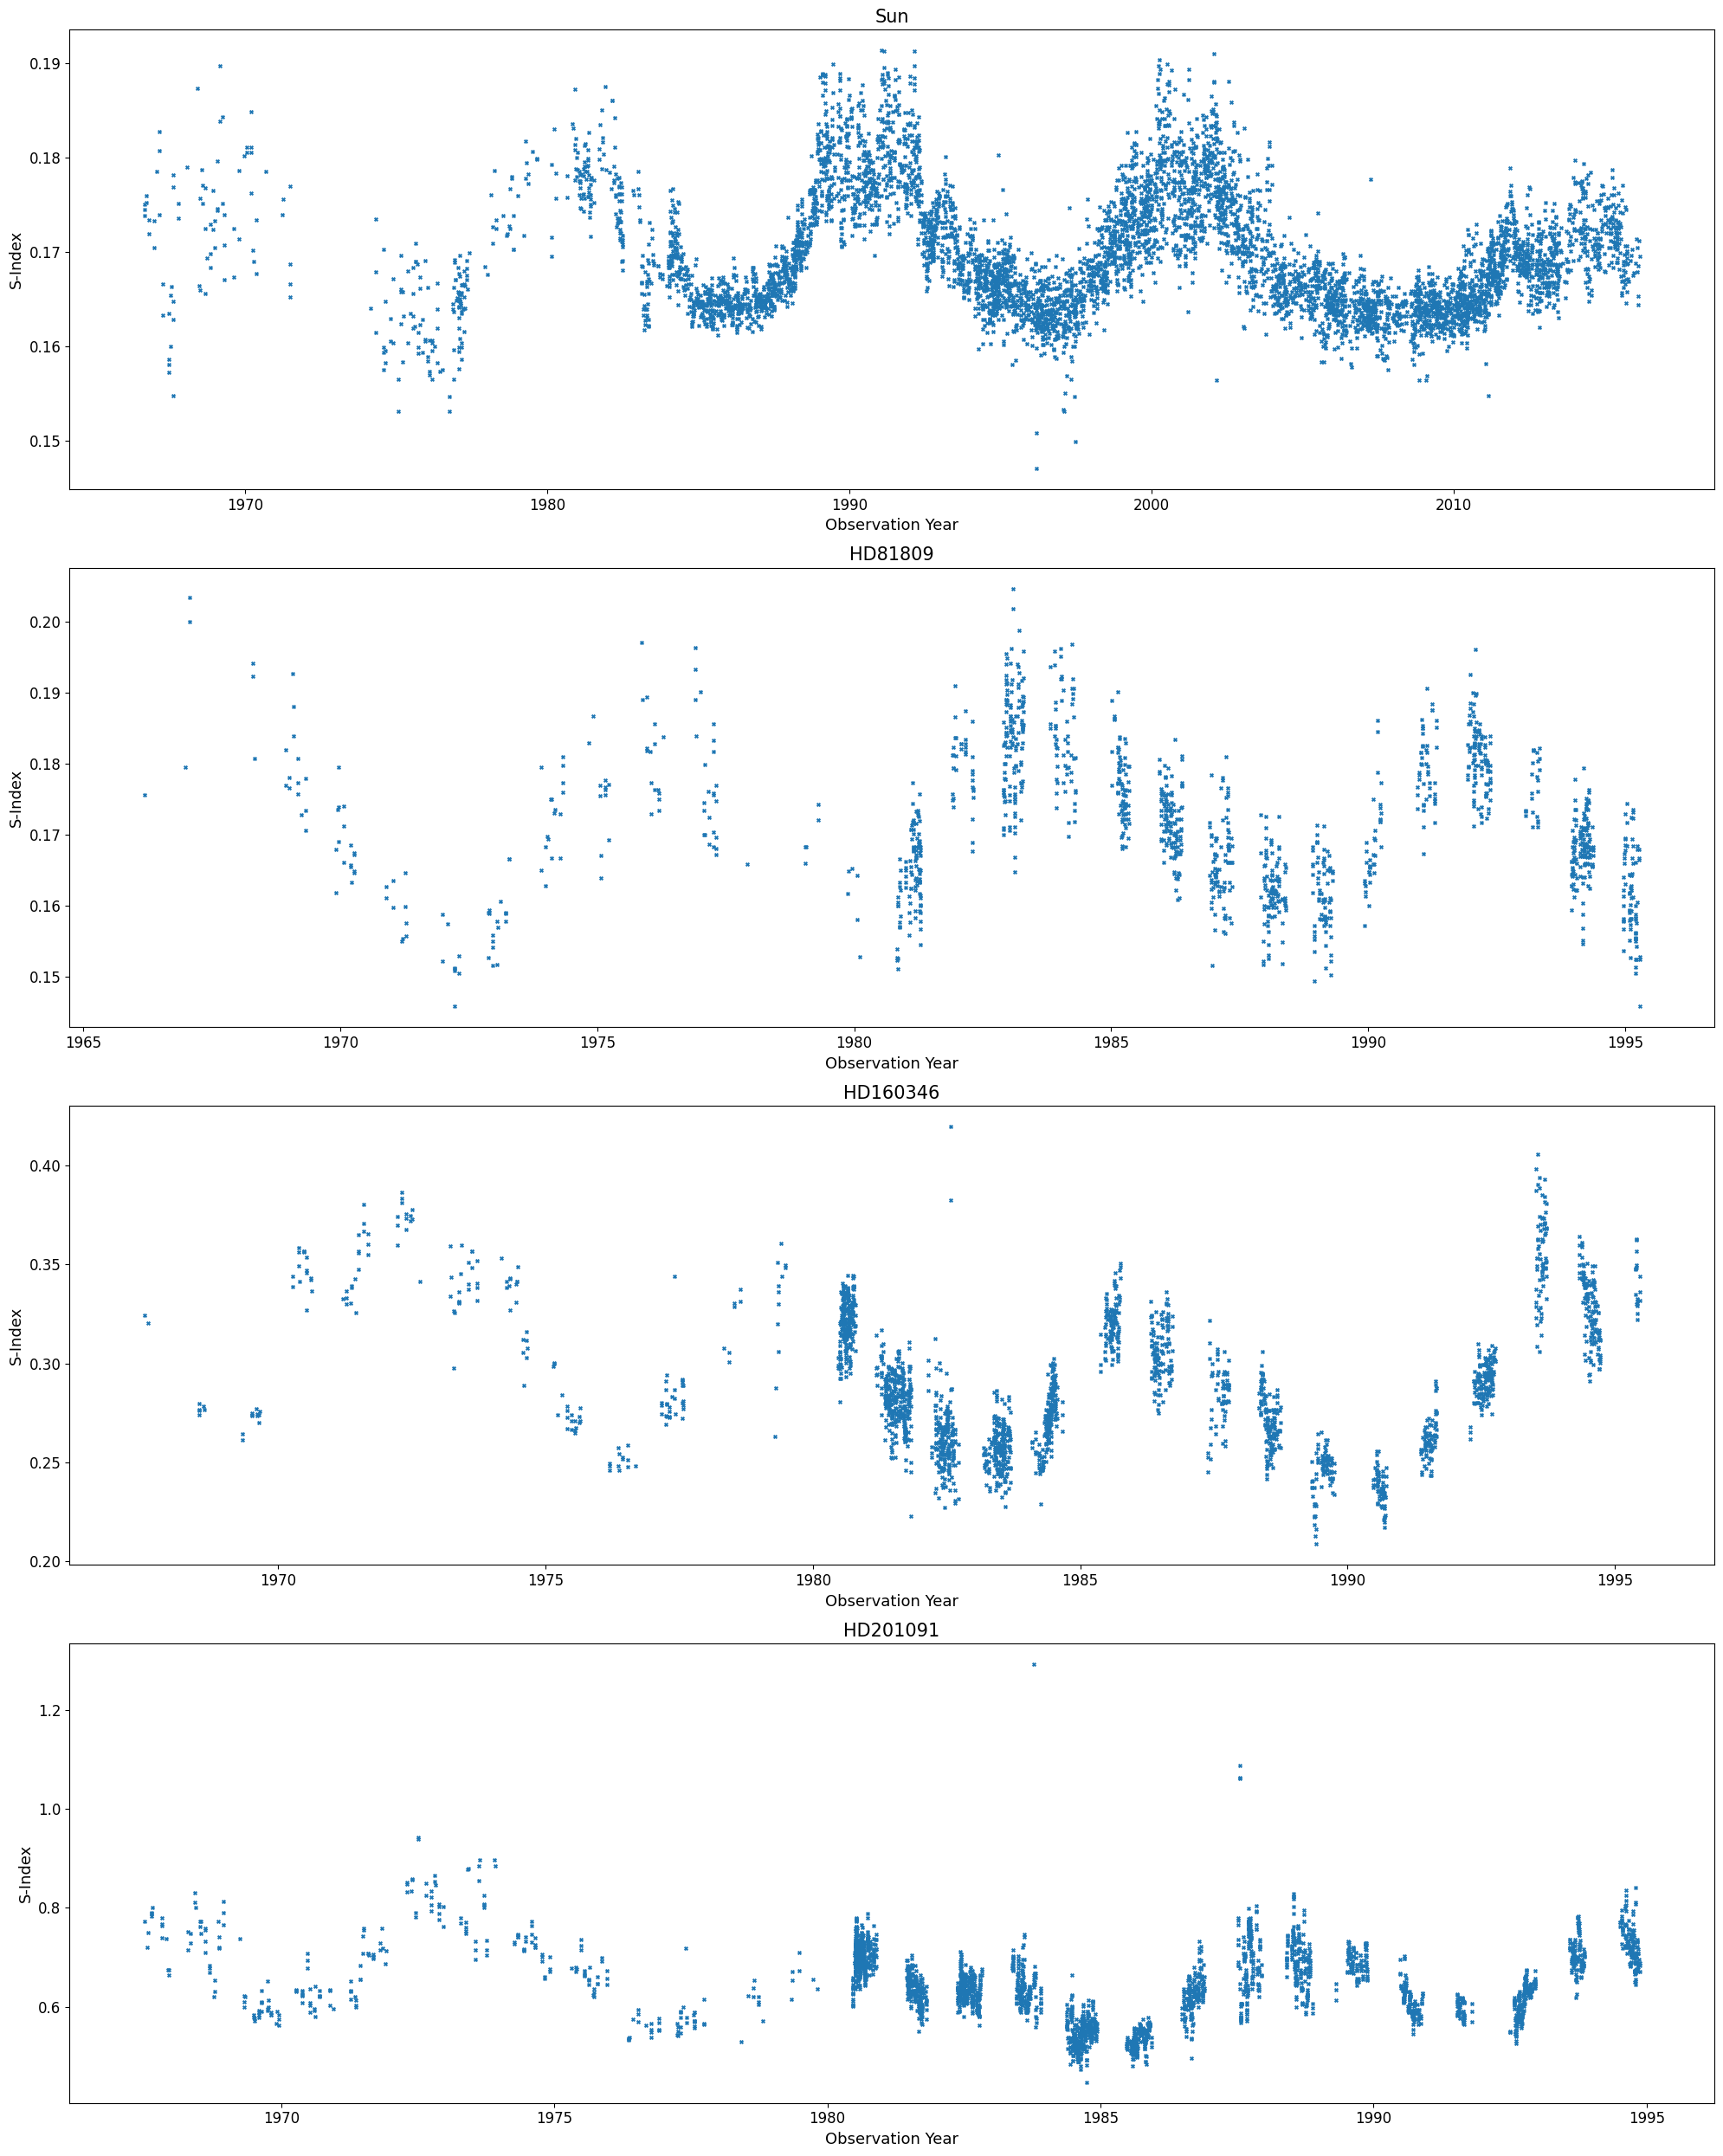

In [9]:
fig, ax = plt.subplots(4, figsize=(20, 25))

# Sun
data = read_csv(r"../Data/misc/sol_sind_all.txt", sep='\s',skip_blank_lines=True).to_numpy()

t = Time(data[:,0], format="jd", scale='tdb') + 2400000
jd_0 = t[0].jd
jd = t.jd - jd_0


ax[0].scatter(t.jyear, data[:,1], marker='x', s=7, alpha=1)
ax[0].set_ylabel("S-Index", fontsize=13)
ax[0].set_xlabel("Observation Year", fontsize=13)
ax[0].tick_params(axis='both', labelsize=12)
ax[0].set_title("Sun", fontsize=15)

# 81809
data = read_csv(r"../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True).to_numpy()
t = Time(data[:,0], format="jd", scale='tdb') 
jd_0 = t[0].jd
jd = t.jd - jd_0

ax[1].scatter(t.jyear, data[:,1], marker='x', s=7, alpha=1)
ax[1].set_ylabel("S-Index", fontsize=13)
ax[1].set_xlabel("Observation Year", fontsize=13)
ax[1].tick_params(axis='both', labelsize=12)
ax[1].set_title("HD81809", fontsize=15)

#HD160346
data = read_csv(r"../Data/benchmark/HD160346_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True).to_numpy()
t = Time(data[:,0], format="jd", scale='tdb') 
jd_0 = t[0].jd
jd = t.jd - jd_0

ax[2].scatter(t.jyear, data[:,1], marker='x', s=7, alpha=1)
ax[2].set_ylabel("S-Index", fontsize=13)
ax[2].set_xlabel("Observation Year", fontsize=13)
ax[2].tick_params(axis='both', labelsize=12)
ax[2].set_title("HD160346", fontsize=15)

# HD201091
data = read_csv(r"../Data/benchmark/HD201091_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True).to_numpy()
t = Time(data[:,0], format="jd", scale='tdb') 
jd_0 = t[0].jd
jd = t.jd - jd_0

ax[3].scatter(t.jyear, data[:,1], marker='x', s=7, alpha=1)
ax[3].set_ylabel("S-Index", fontsize=13)
ax[3].set_xlabel("Observation Year", fontsize=13)
ax[3].tick_params(axis='both', labelsize=12)
ax[3].set_title("HD201091", fontsize=15)

# Save
plt.tight_layout()
fig.savefig(r"../Report/Figures/WellSampledData.png")
plt.show()